In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
from scipy.special import digamma
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
import scienceplots

In [2]:
plt.style.use(["science", "notebook", "grid"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("running on", DEVICE)

running on cpu


In [3]:
QUICK_TRAINING = False

# set seed
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

# folders
DATADIR = "data"
MODELDIR = "models"
for d in [DATADIR, MODELDIR]:
    os.makedirs(d, exist_ok=True)

# define priors
PRIORS = {
    "a": [0.5, 2.0],
    "sigma": [0.05, 0.3]
}
PARAM_NAMES = list(PRIORS.keys())

# model settings
N_SUMMARY = 4
N_FILTERS = 16 # default encoder width
FILTER_LIST = [4, 8, 16, 32]

W_REG = 2.0 # weight of the regression loss
BETA = 1.0 # weight of the KL term in the VAE loss
TOBS = 64
TWARMUP = 64
DT = 0.05

# training settings
if QUICK_TRAINING:
    N_TRAIN, N_TEST = 800, 400
    EPOCHS = 15
    FILTER_LIST = [4, 16]
    SWEEP_SEEDS = [0]
else:
    N_TRAIN, N_TEST = 3000, 800
    EPOCHS = 60
    SWEEP_SEEDS = [0, 1, 2] # each width of the sweep is trained 3 times

N_MI = 1200 # number of test points used for MI estimates

## Bistable Model

The data we use are a discretized stochastic double well:
$$x_{t+1} = x_t + dt\cdot(a\cdot x_t - x_t^3) + \sigma\cdot\sqrt{dt}\cdot\varepsilon_t, \qquad \varepsilon_t \sim N(0,1)$$
with potential
$$V(x) = -a x^2 / 2 + x^4 /4$$

For $a>0$ the potential has two minima $x=\pm \sqrt{a}$, so with the same parameters the trajectory can go to the left or the right well, depending on the noise.

The two parameters to infer are $a$, that decides the separation between the two wells, and $\sigma$, which decides the trajectory jittering.

In [4]:
def generate_dataset(n_samples, stats=None):
    # draw random parameters
    a = np.random.uniform(*PRIORS["a"], n_samples)
    sigma = np.random.uniform(*PRIORS["sigma"], n_samples)

    # define noise and data samples
    eps = np.random.randn(n_samples, TWARMUP + TOBS)
    x = np.zeros(n_samples)
    X = np.zeros((n_samples, TOBS), dtype=np.float32)

    # generate samples
    for t in range(TWARMUP+TOBS):
        x = x + DT * (a * x - x**3) + sigma * np.sqrt(DT) * eps[:, t]
        if t >= TWARMUP:
            X[:, t-TWARMUP] = x
    Noise = eps[:, TWARMUP:].astype(np.float32)
    Params = np.stack([a, sigma], axis=1).astype(np.float32)

    # normalize x and parameters (noise already normalized)
    if stats is None:
        # store values to un-normalize data
        stats = {"x_mean": X.mean(), "x_std": X.std(),
                 "p_mean": Params.mean(0), "p_std": Params.std(0)}
    Xn = (X - stats["x_mean"]) / stats["x_std"]
    Pn = (Params - stats["p_mean"]) / stats["p_std"]

    return Xn, Noise, Pn, Params, stats

def get_data(n, tag, stats=None):
    # data backup so we do not regenerate data at each run
    path = os.path.join(DATADIR, f"{tag}_{n}.npz")
    if os.path.isfile(path):
        d = np.load(path, allow_pickle=True)
        st = stats if stats is not None else d["stats"].item()
        return d["X"], d["N"], d["P"], d["Praw"], st
    X, N, P, Praw, st = generate_dataset(n, stats=stats)
    np.savez(path, X=X, N=N, P=P, Praw=Praw, stats=st)
    return X, N, P, Praw, st

In [5]:
Xtr, Ntr, Ptr, Ptr_raw, stats = get_data(N_TRAIN, "train")
Xte, Nte, Pte, Pte_raw, _ = get_data(N_TEST, "test", stats=stats)

print(f"train: {Xtr.shape}\ntest: {Xte.shape}")

train: (3000, 64)
test: (800, 64)


These are 3 plots of a few trajectories to see the two wells and the different noise levels.
The dashed lines are the two wells at $x=\pm \sqrt{a}$.

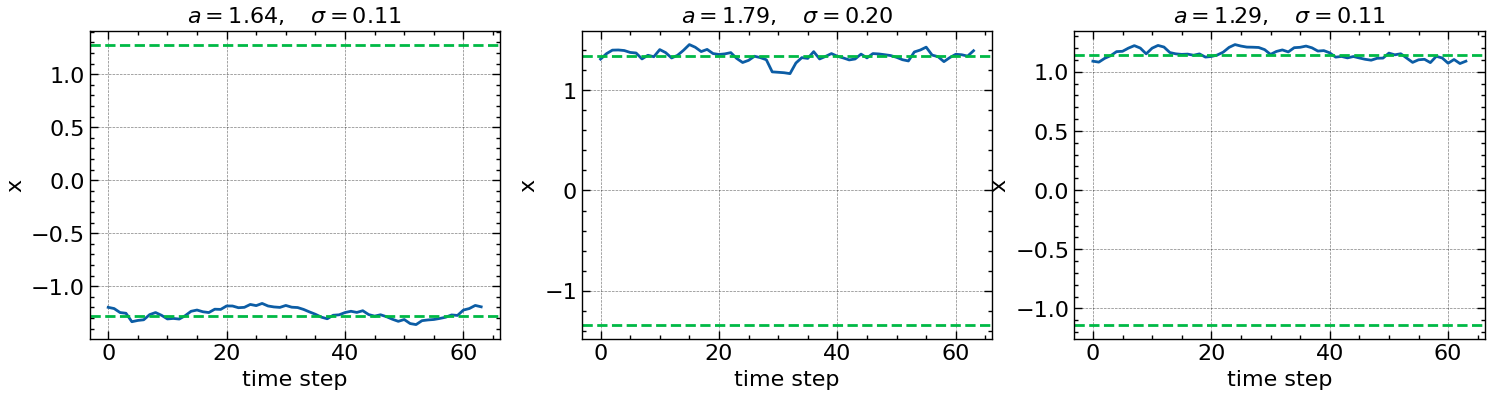

In [6]:
fig,axes = plt.subplots(1,3,figsize=(18,4))
for j in range(3):
    ax = axes[j]
    i = np.random.randint(N_TRAIN)
    x = Xtr[i] * stats["x_std"] + stats["x_mean"]
    ax.plot(x)

    # line of the corresponding two wells
    list_y = [np.sqrt(Ptr_raw[i,0]), -np.sqrt(Ptr_raw[i,0])]
    for y in list_y:
        ax.axhline(y, c="C1", ls="--")
    ax.set_title(f"$a = {Ptr_raw[i,0]:.2f},\quad \sigma = {Ptr_raw[i,1]:.2f}$")
    ax.set_xlabel("time step")
    ax.set_ylabel("x")

plt.show()

## ENCA Architecture
An autoencoder composed by:
- an encoder, a 1D CNN that compresses the series into N_SUMMARY numbers;
- a decoder, a small biLSTM that receives as input the summaries and the bare noise eps, and from that it has to rebuild the series. Since the noise is conditioned, the encoder has no reason to map it in the latent space.

In [7]:
class Encoder(nn.Module):
    def __init__(self, n_summary, n_filters=16):
        super().__init__()
        f = n_filters
        # two input channels: the series and its increments
        self.net = nn.Sequential(
            nn.Conv1d(2, f, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(f, f, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(f, 2*f, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(2*f, n_summary, kernel_size=3, padding=1),
        )
        # we pool mean and std, so the head sees both -> 2*n_summary in
        self.head = nn.Linear(2 * n_summary, n_summary)

    def forward(self, x):
        dx = torch.diff(x, dim=1, prepend=x[:, :1])
        h = torch.stack([x, dx], dim=1)        # (batch, 2, T)
        h = self.net(h)
        feat = torch.cat([h.mean(-1), h.std(-1)], dim=-1)
        return self.head(feat)


class Decoder(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_summary + 1, hidden_size=16,
                            num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, s, noise):
        # tile the summaries along time and stick the noise next to them
        s_tiled = s.unsqueeze(1).expand(-1, noise.shape[1], -1)
        inp = torch.cat([s_tiled, noise.unsqueeze(2)], dim=-1)
        out, _ = self.lstm(inp)
        return self.fc(out).squeeze(-1)


class ENCA(nn.Module):
    def __init__(self, n_summary, n_filters=16):
        super().__init__()
        self.encoder = Encoder(n_summary, n_filters=n_filters)
        self.decoder = Decoder(n_summary)

    def forward(self, x, noise):
        s = self.encoder(x)
        x_hat = self.decoder(s, noise)
        return s, x_hat

In [8]:
def train_enca(X, Noise, Params, n_filters=16, epochs=60, batch_size=128,
               lr=1e-3, verbose=True):
    # initialize the training by specifying the hyperparameters
    n_params = Params.shape[1]
    loader = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(Noise), torch.tensor(Params)),
                        batch_size=batch_size, shuffle=True)

    model = ENCA(N_SUMMARY, n_filters=n_filters).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)
    mse = nn.MSELoss()

    # start training
    model.train()
    for epoch in range(epochs):
        tot = 0.0
        for xb, nb, pb in loader:
            xb, nb, pb = xb.to(DEVICE), nb.to(DEVICE), pb.to(DEVICE)
            s, x_hat = model(xb, nb)
            # reconstruction + parameter regression
            loss = mse(x_hat, xb) + W_REG * mse(s[:, :n_params], pb)

            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += loss.item()
        sched.step()
        if verbose and (epoch + 1) % 20 == 0:
            print(f"  epoch {epoch+1:3d}   loss {tot/len(loader):.4f}")
    return model


def get_summaries(model, X, Noise):
    # summaries S and reconstruction for a whole dataset
    model.eval()
    with torch.no_grad():
        s, x_hat = model(torch.tensor(X).to(DEVICE), torch.tensor(Noise).to(DEVICE))
    return s.cpu().numpy(), x_hat.cpu().numpy()


def get_enca(X, N, P, n_filters, epochs, tag="main"):
    # start the experiment
    path = os.path.join(MODELDIR, f"enca_{tag}_f{n_filters}_s{N_SUMMARY}_n{len(X)}.pt")
    model = ENCA(N_SUMMARY, n_filters=n_filters).to(DEVICE)
    
    if os.path.isfile(path):
        # load model
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.eval()
        return model
    else:
        # train model and then save it
        model = train_enca(X, N, P, n_filters=n_filters, epochs=epochs)
        torch.save(model.state_dict(), path)
        return model

In [9]:
print("training the main ENCA...")
model = get_enca(Xtr, Ntr, Ptr, N_FILTERS, EPOCHS)

S_te, Xhat_te = get_summaries(model, Xte, Nte)
recon_mse = float(np.mean((Xhat_te - Xte) ** 2))
print("test reconstruction MSE:", round(recon_mse, 4))

training the main ENCA...
test reconstruction MSE: 0.0081


A few reconstructions:

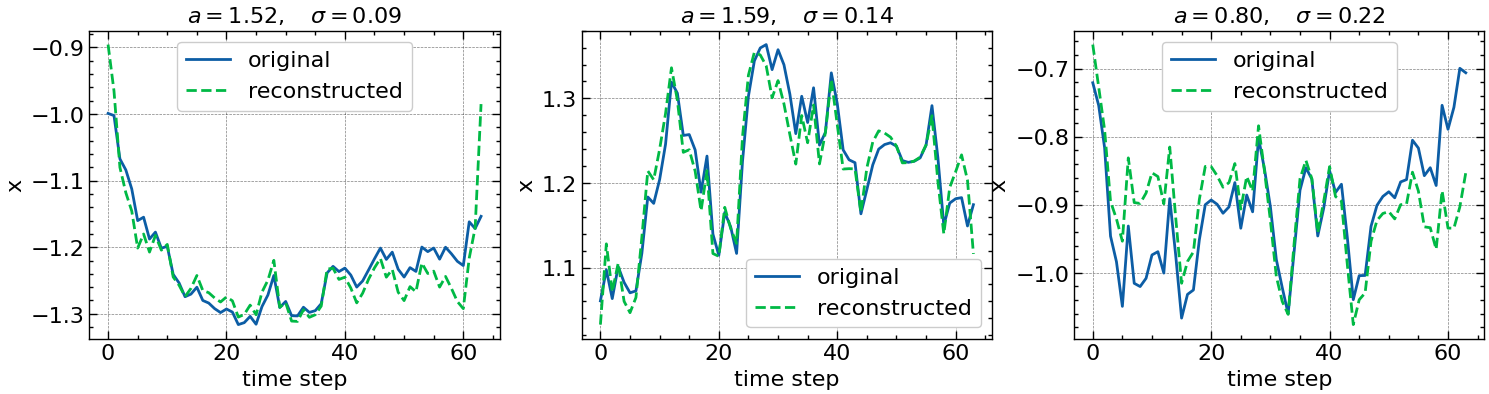

In [10]:
fig,axes = plt.subplots(1,3,figsize=(18,4))
for j in range(3):
    ax = axes[j]
    i = np.random.randint(N_TEST)
    x = Xte[i] * stats["x_std"] + stats["x_mean"]
    xh = Xhat_te[i] * stats["x_std"] + stats["x_mean"]
    
    ax.plot(x, label="original")
    ax.plot(xh, label="reconstructed", ls="--")

    ax.set_title(f"$a = {Pte_raw[i,0]:.2f},\quad \sigma = {Pte_raw[i,1]:.2f}$")
    ax.set_xlabel("time step")
    ax.set_ylabel("x")
    ax.legend()

plt.show()

Check whether the two parameters were retrieved correctly by the summaries:

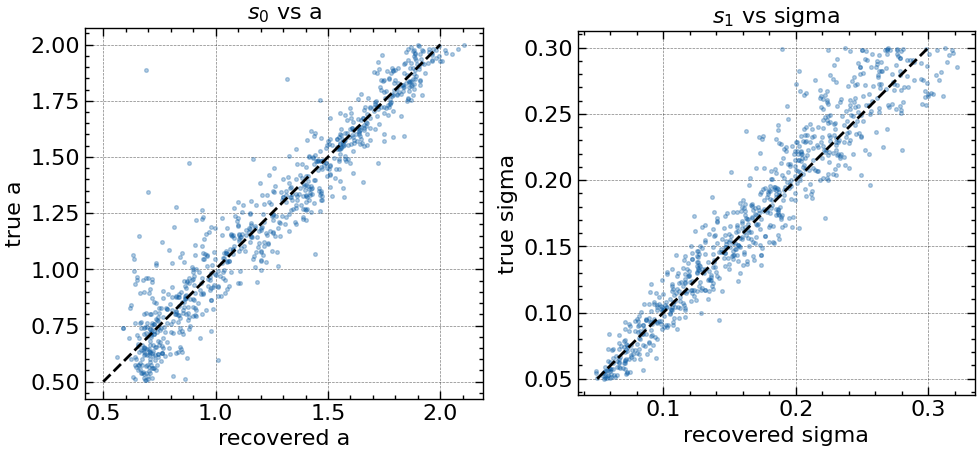

In [11]:
# scatterplot
fig,axes = plt.subplots(1,2,figsize=(10,5))
for j,name in enumerate(PARAM_NAMES):
    ax = axes[j]
    # de-normalize parameters to physical units
    s_real = S_te[:, j] * stats["p_std"][j] + stats["p_mean"][j]
    low, high = PRIORS[name]

    ax.scatter(s_real, Pte_raw[:,j], s=7, alpha=0.3)
    ax.plot([low,high], [low,high], c="k", ls="--")
    ax.set_title(f"$s_{j}$ vs {name}")
    ax.set_xlabel(f"recovered {name}")
    ax.set_ylabel(f"true {name}")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [12]:
def r2_score(true, pred):
    # fraction of the variance of the true values explained by the prediction (1 = perfect, 0 = useless)
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2)
    return 1 - ss_res / ss_tot

# R^2 of the recovered parameters (in physical units)
for j,name in enumerate(PARAM_NAMES):
    s_real = S_te[:, j] * stats["p_std"][j] + stats["p_mean"][j]
    print(f"R^2 of {name}: {r2_score(Pte_raw[:,j], s_real):.3f}")

R^2 of a: 0.912
R^2 of sigma: 0.912


## Mutual Information Estimators
$$I[X:Y] = \int \int p(x,y) \log \left( \frac{p(x,y)}{p(x)\,p(y)} \right ) dx dy$$
We need mutual information between continuous variables but we don't know the densities. To solve this problem, we use three methods (binning, KDE, KSG) to go from the samples to a number: the first two rebuild the probability densities, KSG avoids them.

### 1. Classic binning
Generate the histogram from the scatterplot and pretend it's exactly the probability density. From there, we use that information to calculate the Shannon entropy for this formula:
$$I[X:Y] = H[X] + H[Y] - H[X,Y]$$
to calculate MI.

In [13]:
def _as2d(a):
    # convert a list of points to an array and reshape it in 2D
    a = np.asarray(a, dtype=np.float64)
    if a.ndim == 1:
        a = a.reshape(-1,1)
    
    return a

def entropy_binning(x, bins=20):
    # separate in bins
    counts, _ = np.histogramdd(x, bins=bins)
    # normalize binning count
    p = counts / counts.sum()
    p = p[p>0]
    
    # calculate Shannon entropy
    h = float(-np.sum(p * np.log(p)))
    
    return h

def mi_binning(x, y, bins=20):
    # preprocess the arrays x, y, xy
    x, y = _as2d(x), _as2d(y)
    xy = np.concatenate([x, y], axis=1)

    # calculate MI
    mi = entropy_binning(x,bins) + entropy_binning(y,bins) - entropy_binning(xy,bins)

    return mi

### 2. Kernel Density Estimation (KDE)
Here we use the fact that, given the probability densities from KDE, the MI is just the average on the true distribution. Since our data are samples taken from the true distribution, we can replace the integral with the average on our data:
$$I[X:Y] = \left<\ \log\, p(x,y) - \log\, p(x) - \log\, p(y)  \ \right>$$

In [14]:
def mi_kde(x, y):
    # preprocess the arrays x, y, xy
    x, y = _as2d(x), _as2d(y)
    xy = np.concatenate([x, y], axis=1)

    # calculate log probabilites from the KDE
    log_px = gaussian_kde(x.T).logpdf(x.T)
    log_py = gaussian_kde(y.T).logpdf(y.T)
    log_pxy = gaussian_kde(xy.T).logpdf(xy.T)

    # calculate MI
    mi = float(np.mean(log_pxy - log_px - log_py))

    return mi

### 3. Kraskov (KSG)
Instead of relying on probability densities we have an idea of the information just by checking the points' neighbors distance. A point that has many neighbors in a small region of space hints to a dependence between the two variables.

For each point we create the smallest square (max-norm) around it that contains its $k$ nearest neighbors in the joint $(x,y)$ plane. Then we look at the vertical strip that has the same width of the square (same range in $x$, any $y$) and we count how many points fall inside it, $n_x$. Same thing with the horizontal strip, $n_y$.
If X and Y are unrelated, the strips catch many more points than the square, $n_x, n_y \gg k$. If they are related, the strips catch more or less the same points of the square, $n_x, n_y \approx k$.

We could express the mutual information using this formula:
$$\hat{I}[X:Y] = \log \left( \frac{k\cdot N}{n_x\cdot n_y} \right )$$
which is 0 when the fraction of points in the square ($k/N$) is the product of the fractions in the two strips ($n_x/N \cdot n_y/N$), that is exactly independence. But the logarithm would add a bias term for small counts, that is easily removed using instead the digamma function $\psi$. So, the formula used to calculate MI is:
$$\hat{I}[X:Y] = \psi(k) + \psi(N) - \left< \psi(n_x +1)+ \psi(n_y +1) \right >$$

In [15]:
def mi_kraskov(x, y, k=5):
    n = len(x)
    
    # preprocess the arrays x, y, xy
    x, y = _as2d(x), _as2d(y)
    xy = np.concatenate([x, y], axis=1)

    # find the box size (eps) for each point
    dist, _ = cKDTree(xy).query(xy, k=k + 1, p=np.inf) # k=k+1 because the first element found is the point itself
    eps = dist[:, k]

    # count how many points there are inside the strip
    tree_x, tree_y = [cKDTree(v) for v in [x,y]]
    nx, ny = [np.zeros(n) for _ in range(2)]
    for i in range(n):
        nx[i] = len(tree_x.query_ball_point(x[i], eps[i]-1e-12, p=np.inf)) - 1
        ny[i] = len(tree_y.query_ball_point(y[i], eps[i]-1e-12, p=np.inf)) - 1

    # calculate MI
    mi = float(digamma(k) + digamma(n) - np.mean(digamma(nx + 1) + digamma(ny + 1)))

    return mi    

### Sanity check on a gaussian
Before using the estimators on our data, we test them on a case where we know the answer. For two gaussian variables with correlation $\rho$ the mutual information is exactly
$$I[X:Y] = -\frac{1}{2}\log(1-\rho^2)$$
so we generate pairs with different $\rho$ and we compare the three methods with the formula.

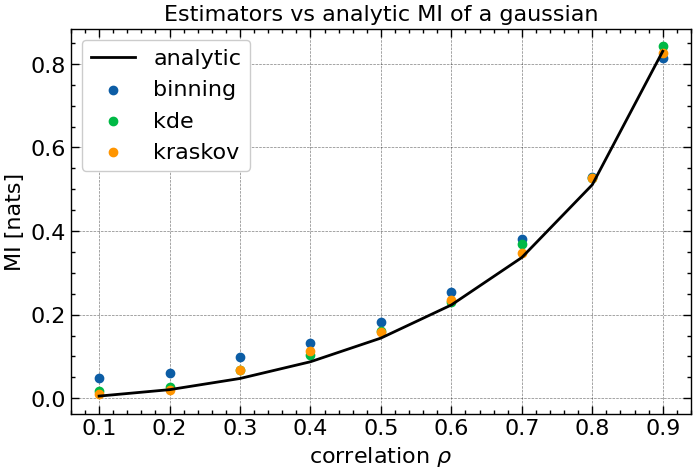

In [16]:
# correlations to test
rhos = np.linspace(0.1, 0.9, 9)
true_mi, bin_mi, kde_mi, kra_mi = [], [], [], []

for rho in rhos:
    # 3000 samples of a 2D gaussian with correlation rho
    sample = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=3000)
    x, y = sample[:, 0], sample[:, 1]

    # exact value and the three estimates
    true_mi.append(-0.5 * np.log(1 - rho**2))
    bin_mi.append(mi_binning(x, y))
    kde_mi.append(mi_kde(x, y))
    kra_mi.append(mi_kraskov(x, y))

fig,ax = plt.subplots(figsize=(8,5))
ax.plot(rhos, true_mi, c="k", label="analytic")
ax.scatter(rhos, bin_mi, label="binning")
ax.scatter(rhos, kde_mi, label="kde")
ax.scatter(rhos, kra_mi, label="kraskov")
ax.set_title("Estimators vs analytic MI of a gaussian")
ax.set_xlabel(r"correlation $\rho$")
ax.set_ylabel("MI [nats]")
ax.legend()
plt.show()

All three follow the analytic curve, so the code works. Binning is a bit above the curve for small $\rho$: with a finite number of points per bin, the random fluctuations of the counts look like structure (positive bias).

## Calculate Mutual Information
Here we actually test whether the summaries keep all the information about the parameters and throw away the noise. The email asks for 4 quantities:
- $\text{MI}(X,\theta)$: how much the whole series tells about the parameters. This is the ceiling, since $s$ is computed from $X$ (data processing inequality).
- $\text{MI}(s,\theta)$: we want $\text{MI}(s,\theta) \approx \text{MI}(X,\theta)$, meaning that the summary statistics have extracted all the information about the parameters inside data (**sufficiency**).
- $\text{MI}(X,\varepsilon)$: the series is built from the noise, so this is huge (formally infinite, see below).
- $\text{MI}(s,\varepsilon)$: we want $\text{MI}(s,\varepsilon) \approx 0$, meaning that the summary statistics ignore the noise (**concentration**).

We don't compare with $H(\theta)$: for continuous parameters the differential entropy is not an upper bound of the MI (for $\sigma$ it's even negative, $\log 0.25 = -1.39$ nats).

First, we compare the three methods where they are all well defined (1D vs 1D).

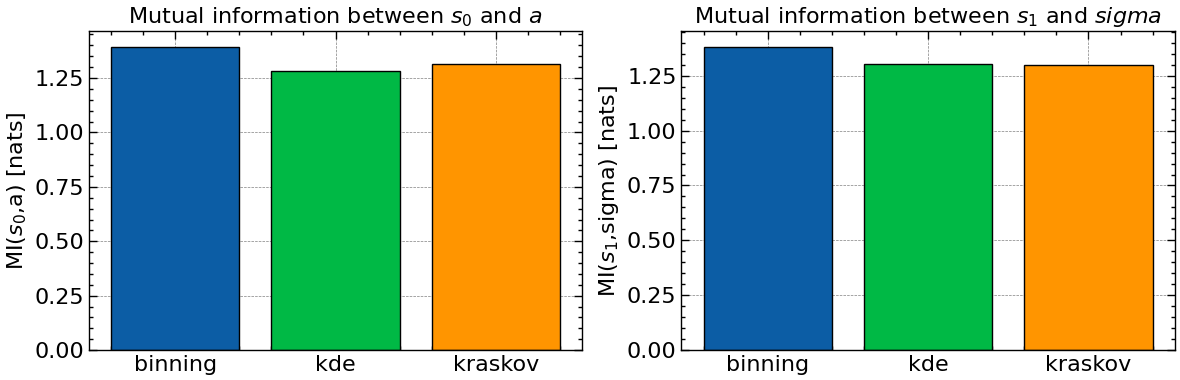

In [17]:
# pick random summaries and parameters from the test set
idx = np.random.choice(N_TEST, min(N_MI, N_TEST), replace=False)
S = S_te[idx]
Params = Pte_raw[idx]

fig,axes = plt.subplots(1,2,figsize=(12,4))
# compare the parameters and summaries
for i in range(2):
    ax = axes[i]
    x = S[:, i:i+1]
    y = Params[:, i:i+1]
    
    # calculate MI with the 3 methods
    results = {
        "binning": mi_binning(x, y, bins=24),
        "kde": mi_kde(x, y),
        "kraskov": mi_kraskov(x, y, k=5)
    }
    
    ax.bar(np.arange(3), list(results.values()), color=[f"C{j}" for j in range(3)], ec="k")
    ax.set_title(f"Mutual information between $s_{i}$ and ${PARAM_NAMES[i]}$")
    ax.set_xticks(np.arange(3), list(results.keys()))
    ax.set_ylabel(f"MI($s_{i}$,{PARAM_NAMES[i]}) [nats]")
fig.tight_layout()
plt.show()

We can see that they all give similar numbers, so we have reliable estimators.

To calculate the 4 MI, we have to deal with a couple of problems:
- $\text{MI}(X,\varepsilon) = h(X)-h(X|\varepsilon)$. In this case, $h(X|\varepsilon)=-\infty$, because $\varepsilon$ (with the few other unknowns) determines X completely. $\implies \text{MI}(X,\varepsilon) = +\infty$
- We are using samples that live in 64 dimensions (TOBS). The three MI estimators work by checking how clustered the points are, and in 64D the distances blow up so much that each sample has no neighbors. Even in the 4D summary we have this kind of problem because only one of the components carries information about $\sigma$, the other three just increase the distances of the points, giving a worse result in calculating MI.

To solve this problem, we follow these steps:
1. take 800 test points and for each of them we guess the true $a$ from $s$. The guessing is done using a k-NN regressor, which finds the 15 points with the most similar $s$, and average their $a$.
2. this creates 800 tuples of 2 numbers: (guess, true value).
3. run Kraskov on these two columns, and this is the answer.

For the data side we can't use the 64 numbers of $X$, so we use 5 hand-made features $\phi(X)$: where the series sits (for $a$) and how big its jumps are (for $\sigma$).

For the noise side there is nothing to guess, so we use Kraskov directly. The trajectory feels the accumulated kicks, so we take the cumulative sum of $\varepsilon$ and we compress it to 6 numbers with PCA. The noise features are much bigger than $s$ (they are sums of 64 kicks), so before Kraskov we standardize every column: otherwise the box size is decided only by the noise and the MI comes out exactly 0, whatever the data are. To have also the $\text{MI}(X,\varepsilon)$ side, we do the same with the first 6 PCA components of $X$ (it's only a lower bound, the true value is infinite).

In [18]:
def standardize(A):
    # every column with mean 0 and std 1, so no column dominates the distances
    A = _as2d(A)
    return (A - A.mean(0)) / (A.std(0) + 1e-9)

def sufficient_features(X):
    # near-sufficient summary of a trajectory: where it sits (a) and how it jumps (sigma)
    # this is our replacement for X
    x = X * stats["x_std"] + stats["x_mean"]
    dx = np.diff(x, axis=1)
    phi = np.stack([x.mean(1), (x**2).mean(1), np.abs(x.mean(1)),
                    dx.std(1), np.abs(dx).mean(1)], axis=1)

    return phi

def decodable_mi(R, target, k=5, n_neighbors=15, folds=5):
    # how well we can guess the target from R, measured in nats
    Rs = standardize(R)
    n = len(target)
    pred = np.empty(n)

    # 5-fold cross validation: we never guess a point using itself
    order = np.random.permutation(n)
    for fold in np.array_split(order, folds):
        train = np.setdiff1d(order, fold)
        # guess = average target of the 15 most similar points
        knn = KNeighborsRegressor(n_neighbors).fit(Rs[train], target[train])
        pred[fold] = knn.predict(Rs[fold])

    # R^2 of the guesses
    ss_res = np.sum((target - pred) ** 2)
    ss_tot = np.sum((target - target.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    # MI between guess and truth (1D vs 1D)
    return mi_kraskov(pred, target, k=k), r2

In [19]:
# pick random test samples
idx = np.random.choice(N_TEST, min(N_MI, N_TEST), replace=False)
# find the near-sufficient summaries
phiX = sufficient_features(Xte[idx])
# sum noise and project the accumulated sums on 6D by PCA
eps_pca = PCA(6).fit_transform(np.cumsum(Nte[idx], axis=1))
# project the trajectories on 6D by PCA (for the MI between X and the noise)
x_pca = PCA(6).fit_transform(Xte[idx])

# information about the parameters: decodable MI
mi_data, mi_summ = {}, {}
for j, name in enumerate(PARAM_NAMES):
    mi_data[name] = decodable_mi(phiX, Pte_raw[idx, j])[0]
    mi_summ[name] = decodable_mi(S_te[idx], Pte_raw[idx, j])[0]

# information about the noise: Kraskov directly, after standardizing everything
eps_std = standardize(eps_pca)
mi_data["eps"] = mi_kraskov(standardize(phiX), eps_std)
mi_summ["eps"] = mi_kraskov(standardize(S_te[idx]), eps_std)
mi_traj_eps = mi_kraskov(standardize(x_pca), eps_std)
# control: we shuffle the noise so it's not paired with its series anymore (true MI = 0)
shuffle = np.random.permutation(len(idx))
mi_control = mi_kraskov(standardize(x_pca), eps_std[shuffle])

print("          data phi(X)   summaries S")
for key in ["a", "sigma", "eps"]:
    print(f"{key:8s}  {mi_data[key]:.3f}         {mi_summ[key]:.3f}")
print(f"\ntrajectory X vs noise: {mi_traj_eps:.3f}")
print(f"shuffled control:      {mi_control:.3f}")

          data phi(X)   summaries S
a         1.111         1.235
sigma     1.419         1.268
eps       0.016         0.006

trajectory X vs noise: 1.114
shuffled control:      -0.034


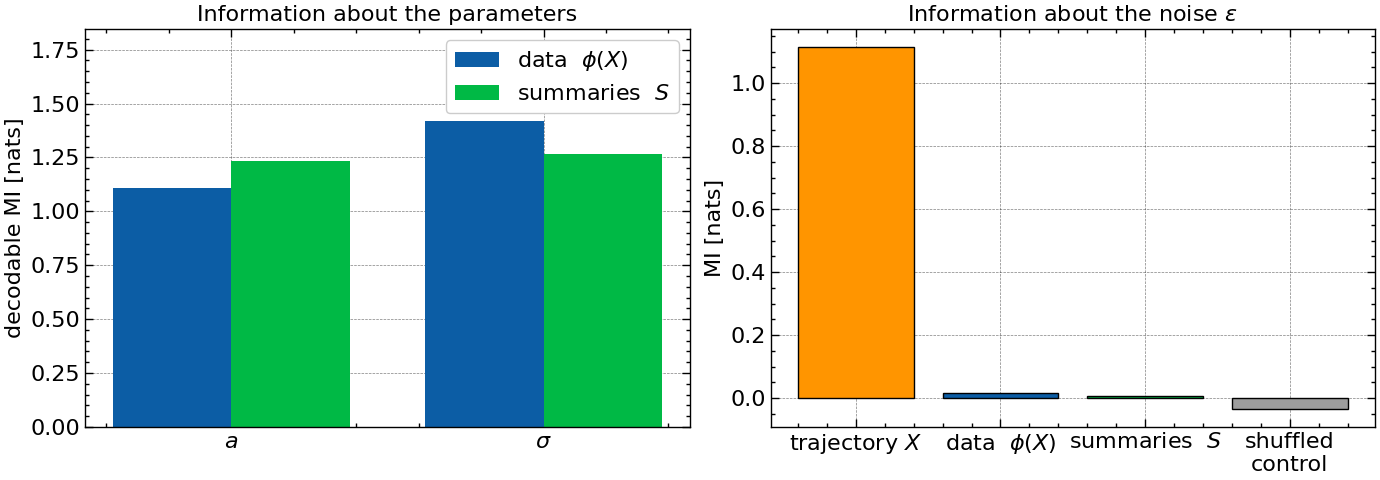

In [20]:
fig,axes = plt.subplots(1,2,figsize=(14,5))

# left: information about the parameters
ax = axes[0]
xpos = np.arange(len(PARAM_NAMES))
w = 0.38
data_vals = [mi_data[name] for name in PARAM_NAMES]
summ_vals = [mi_summ[name] for name in PARAM_NAMES]
ax.bar(xpos - w/2, data_vals, width=w, label="data  $\\phi(X)$")
ax.bar(xpos + w/2, summ_vals, width=w, label="summaries  $S$")
ax.set_title("Information about the parameters")
ax.set_ylabel("decodable MI [nats]")
ax.set_xticks(xpos, ["$a$", "$\\sigma$"])
ax.set_ylim(0, 1.3 * max(data_vals + summ_vals)) # some room for the legend
ax.legend()

# right: information about the noise
ax = axes[1]
noise_vals = [mi_traj_eps, mi_data["eps"], mi_summ["eps"], mi_control]
noise_names = ["trajectory $X$", "data  $\\phi(X)$", "summaries  $S$", "shuffled\ncontrol"]
ax.bar(np.arange(4), noise_vals, color=["C2", "C0", "C1", "C6"], ec="k")
ax.set_title("Information about the noise $\\varepsilon$")
ax.set_ylabel("MI [nats]")
ax.set_xticks(np.arange(4), noise_names)

fig.tight_layout()
plt.show()

On the parameters (left) the summaries $S$ keep about the same information as the hand-made features of the whole series, so the $64 \to 4$ compression keeps (almost) all the information about $a$ and $\sigma$ (**sufficiency**). A value around 1.2 nats means that knowing $S$ makes the uncertainty on the parameter about $e^{1.2}\approx 3.3$ times narrower.
- For $a$ the summaries can come out slightly above $\phi(X)$. This is not against the data processing inequality: $\phi(X)$ is not $X$, it's a compression made by hand, so both bars are lower bounds and the difference is estimator noise.
- For $\sigma$, $\phi(X)$ is a bit better: the std of the increments is almost the perfect statistic for $\sigma$. So $S$ is close to the ceiling, not exactly on it.

On the noise (right) the trajectory carries more than 1 nat about its own noise (and it's only a lower bound, the real value is infinite), while the summaries are at the level of the shuffled control, so $\text{MI}(s,\varepsilon)\approx 0$ (**concentration**). Also $\phi(X)$ ignores the noise: it's a summary designed for $\theta$ too. (Values around 0, even slightly negative, just mean 0 within the noise of the estimator.)

## Filter Sweep
The professor suggested to take one key parameter of the convolutional part and see how the compression changes with it. We take the number of filters of the encoder: more filters = more patterns the CNN can look for = more capacity.

For each width we train the ENCA 3 times with different seeds (the training has some randomness) and we look at $\sigma$, the hard parameter ($a$ is easy and it's learned well also with few filters). We measure:
- $\text{MI}(s_1,\sigma)$: how much information the $\sigma$ summary keeps (1D Kraskov);
- $R^2(\sigma)$: how accurate the $\sigma$ recovery is.

If MI is a good measure of the quality of the compression, the two should grow together.

The first time, this cell trains 12 small models so it takes a while, then they are saved in `models/` and it's fast.

In [21]:
# for every width and every seed: MI and R^2 of sigma (and of a, just to check)
mi_sigma = np.zeros((len(FILTER_LIST), len(SWEEP_SEEDS)))
r2_sigma = np.zeros((len(FILTER_LIST), len(SWEEP_SEEDS)))
mi_a = np.zeros((len(FILTER_LIST), len(SWEEP_SEEDS)))
r2_a = np.zeros((len(FILTER_LIST), len(SWEEP_SEEDS)))

for i, f in enumerate(FILTER_LIST):
    for j, seed in enumerate(SWEEP_SEEDS):
        # same seed -> same initial weights, so the result is reproducible
        torch.manual_seed(seed)
        m = get_enca(Xtr, Ntr, Ptr, f, EPOCHS, tag=f"sweep{seed}")
        S_f, _ = get_summaries(m, Xte, Nte)

        # de-normalize the two parameter summaries
        a_rec = S_f[:, 0] * stats["p_std"][0] + stats["p_mean"][0]
        sigma_rec = S_f[:, 1] * stats["p_std"][1] + stats["p_mean"][1]

        mi_a[i,j] = mi_kraskov(a_rec, Pte_raw[:, 0])
        mi_sigma[i,j] = mi_kraskov(sigma_rec, Pte_raw[:, 1])
        r2_a[i,j] = r2_score(Pte_raw[:, 0], a_rec)
        r2_sigma[i,j] = r2_score(Pte_raw[:, 1], sigma_rec)

    print(f"filters = {f:2d}   MI(s1,sigma) = {mi_sigma[i].mean():.3f} +- {mi_sigma[i].std():.3f}   "
          f"R2(sigma) = {r2_sigma[i].mean():.3f} +- {r2_sigma[i].std():.3f}   "
          f"MI(s0,a) = {mi_a[i].mean():.3f}   R2(a) = {r2_a[i].mean():.3f}")

  epoch  20   loss 1.1408
  epoch  40   loss 1.0543
  epoch  60   loss 0.9181
  epoch  20   loss 1.8761
  epoch  40   loss 1.7949
  epoch  60   loss 1.7529
  epoch  20   loss 1.5900
  epoch  40   loss 1.4474
  epoch  60   loss 1.3080
filters =  4   MI(s1,sigma) = 0.143 +- 0.102   R2(sigma) = 0.077 +- 0.082   MI(s0,a) = 1.066   R2(a) = 0.646
  epoch  20   loss 1.0827
  epoch  40   loss 0.9167
  epoch  60   loss 0.7521
  epoch  20   loss 1.0556
  epoch  40   loss 0.8971
  epoch  60   loss 0.6057
  epoch  20   loss 0.8850
  epoch  40   loss 0.4793
  epoch  60   loss 0.3695
filters =  8   MI(s1,sigma) = 0.467 +- 0.125   R2(sigma) = 0.498 +- 0.133   MI(s0,a) = 1.229   R2(a) = 0.894
  epoch  20   loss 1.0227
  epoch  40   loss 0.1917
  epoch  60   loss 0.1582
  epoch  20   loss 0.7194
  epoch  40   loss 0.3507
  epoch  60   loss 0.2694
  epoch  20   loss 0.8517
  epoch  40   loss 0.3903
  epoch  60   loss 0.2956
filters = 16   MI(s1,sigma) = 1.020 +- 0.227   R2(sigma) = 0.825 +- 0.066   MI(s

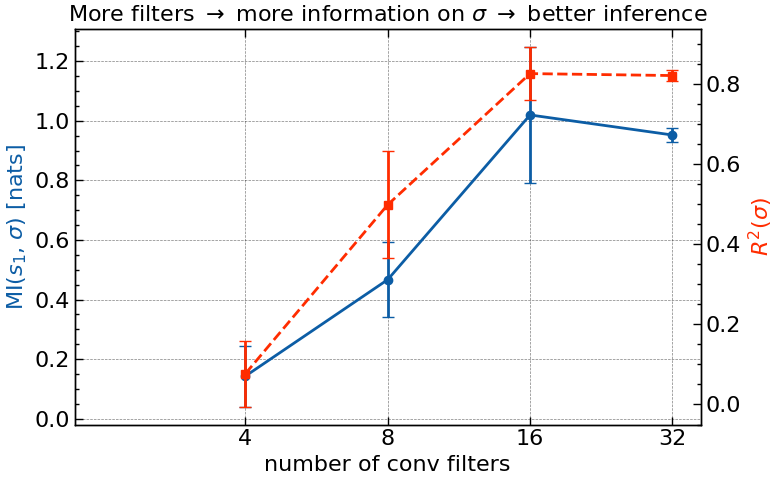

In [22]:
fig,ax1 = plt.subplots(figsize=(8,5))

# left axis: information on sigma
ax1.errorbar(FILTER_LIST, mi_sigma.mean(1), yerr=mi_sigma.std(1), fmt="o-", c="C0", capsize=4)
ax1.set_xscale("log", base=2)
ax1.set_xticks(FILTER_LIST, [str(f) for f in FILTER_LIST])
ax1.set_xlabel("number of conv filters")
ax1.set_ylabel("MI($s_1$, $\\sigma$) [nats]", c="C0")

# right axis: accuracy of the sigma recovery
ax2 = ax1.twinx()
ax2.errorbar(FILTER_LIST, r2_sigma.mean(1), yerr=r2_sigma.std(1), fmt="s--", c="C3", capsize=4)
ax2.set_ylabel("$R^2(\\sigma)$", c="C3")
ax2.grid(False)

ax1.set_title("More filters $\\to$ more information on $\\sigma$ $\\to$ better inference")
fig.tight_layout()
plt.show()

The two curves grow together: a wider encoder keeps more information about $\sigma$ and at the same time recovers it better, so MI is a good diagnostic of how well the network is compressing. The error bars (spread over the seeds) show that the training has some luck in it, but the trend is clear: it grows a lot at the beginning and then it starts to saturate.

Note: MI and $R^2$ are strongly related, with gaussian errors $\text{MI} \approx -\frac{1}{2}\log(1-R^2)$ (same formula of the gaussian check), so they are two readings of the same thing. What we learn is that the capacity of the encoder is the bottleneck for $\sigma$, and that MI sees it.

## Comparison with a plain VAE
The last point of the email: a classic variational autoencoder (Kingma & Welling) with the same latent size (4), but with **no noise given to the decoder** and **no regression on the parameters**. It only compresses $x$ and rebuilds it.
- the encoder gives, for each latent number, a mean $\mu$ and a log-variance $\log s^2$;
- we sample $z = \mu + s\cdot\eta$ with $\eta \sim N(0,1)$ (reparametrization trick, so we can still do backpropagation). This $\eta$ has nothing to do with the physical noise $\varepsilon$;
- the decoder rebuilds $x$ from $z$;
- loss = reconstruction + $\beta\cdot$KL, where the KL term pushes the latent distribution towards a standard gaussian:
$$\text{KL} = -\frac{1}{2}\sum_{j=1}^{4}\left(1 + \log s_j^2 - \mu_j^2 - s_j^2\right)$$

Like in the Kingma-Welling paper, the reconstruction is the sum of the squared errors over the 64 time steps and the KL is summed over the 4 latent numbers (then we average over the batch), with $\beta = 1$.

Since it doesn't have the noise, the VAE can't redraw the exact wiggles, and their size ($\sigma$) barely changes the reconstruction error, so we expect it to keep $a$ but to lose $\sigma$.

In [23]:
class VAE(nn.Module):
    def __init__(self, input_size, latent_dim, hidden=128):
        super().__init__()
        # encoder: series -> hidden layers -> mean and log-variance of the latent
        self.enc = nn.Sequential(nn.Linear(input_size, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU())
        self.fc_mu = nn.Linear(hidden, latent_dim)
        self.fc_logvar = nn.Linear(hidden, latent_dim)
        # decoder: latent -> hidden layers -> series
        self.dec = nn.Sequential(nn.Linear(latent_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, input_size))

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        # reparametrization trick: z = mu + std * gaussian noise
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.dec(z), mu, logvar


def train_vae(X, latent_dim, epochs=60, batch_size=128, lr=1e-3, beta=1.0, verbose=True):
    # initialize the training (only the series, no noise and no parameters)
    loader = DataLoader(TensorDataset(torch.tensor(X)), batch_size=batch_size, shuffle=True)

    model = VAE(X.shape[1], latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # start training
    model.train()
    for epoch in range(epochs):
        tot = 0.0
        for batch in loader:
            xb = batch[0].to(DEVICE)
            x_hat, mu, logvar = model(xb)
            # sum over the time steps and over the latent numbers, mean over the batch
            recon = ((x_hat - xb) ** 2).sum(1).mean()
            kl = (-0.5 * (1 + logvar - mu**2 - logvar.exp())).sum(1).mean()
            loss = recon + beta * kl

            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += loss.item()
        if verbose and (epoch + 1) % 20 == 0:
            print(f"  epoch {epoch+1:3d}   loss {tot/len(loader):.4f}")
    return model


def get_vae(X, epochs, beta=1.0, tag="main"):
    # same idea of get_enca: load the model if it's already saved, otherwise train it and save it
    path = os.path.join(MODELDIR, f"vae_{tag}_l{N_SUMMARY}_n{len(X)}.pt")
    model = VAE(X.shape[1], N_SUMMARY).to(DEVICE)

    if os.path.isfile(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.eval()
        return model
    else:
        model = train_vae(X, N_SUMMARY, epochs=epochs, beta=beta)
        torch.save(model.state_dict(), path)
        return model


def get_latents(model, X):
    # latent of each series (we use the mean mu, not a random sample) and the reconstruction from it
    model.eval()
    with torch.no_grad():
        mu, _ = model.encode(torch.tensor(X).to(DEVICE))
        x_hat = model.dec(mu)
    return mu.cpu().numpy(), x_hat.cpu().numpy()

In [24]:
print("training the VAE...")
torch.manual_seed(SEED)
vae = get_vae(Xtr, EPOCHS, beta=BETA)

Z_te, Xhat_vae = get_latents(vae, Xte)
vae_mse = float(np.mean((Xhat_vae - Xte) ** 2))
print("VAE test reconstruction MSE: ", round(vae_mse, 4))
print("ENCA test reconstruction MSE:", round(recon_mse, 4))

# same measurements as before, but on the VAE latent Z
mi_vae = {}
for j, name in enumerate(PARAM_NAMES):
    mi_vae[name] = decodable_mi(Z_te[idx], Pte_raw[idx, j])[0]
mi_vae["eps"] = mi_kraskov(standardize(Z_te[idx]), eps_std)

print("\n          ENCA S    VAE Z")
for key in ["a", "sigma", "eps"]:
    print(f"{key:8s}  {mi_summ[key]:.3f}     {mi_vae[key]:.3f}")

training the VAE...
  epoch  20   loss 3.4699
  epoch  40   loss 3.2317
  epoch  60   loss 3.1404
VAE test reconstruction MSE:  0.013
ENCA test reconstruction MSE: 0.0081

          ENCA S    VAE Z
a         1.235     0.926
sigma     1.268     0.044
eps       0.006     0.101


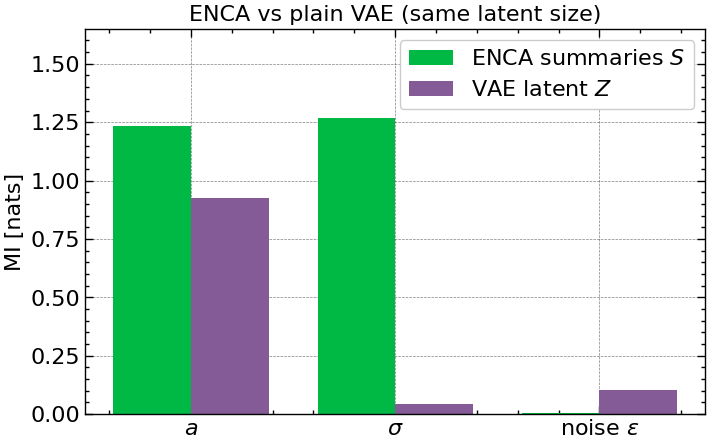

In [25]:
groups = ["a", "sigma", "eps"]
enca_vals = [mi_summ[g] for g in groups]
vae_vals = [mi_vae[g] for g in groups]
xpos = np.arange(len(groups))
w = 0.38

fig,ax = plt.subplots(figsize=(8,5))
ax.bar(xpos - w/2, enca_vals, width=w, color="C1", label="ENCA summaries $S$")
ax.bar(xpos + w/2, vae_vals, width=w, color="C4", label="VAE latent $Z$")
ax.set_title("ENCA vs plain VAE (same latent size)")
ax.set_ylabel("MI [nats]")
ax.set_xticks(xpos, ["$a$", "$\\sigma$", "noise $\\varepsilon$"])
ax.set_ylim(0, 1.3 * max(enca_vals + vae_vals)) # some room for the legend
ax.legend()
plt.show()

Both keep the information about $a$, the easy and dominant feature. On $\sigma$ the difference is huge: the ENCA keeps it, the VAE almost throws it away (the ENCA makes the uncertainty on $\sigma$ about 3 times narrower, the VAE basically doesn't narrow it at all). The reason is the one we expected: without the noise the VAE can't redraw the wiggles, and their size barely changes its reconstruction error, so storing $\sigma$ is not worth it. The ENCA gets the wiggles for free from $\varepsilon$, so the only thing left to learn is the parameters.

On the noise it's the opposite: the VAE latent keeps some information about the noise realization (above the shuffled control), while the ENCA summaries don't. The VAE uses part of its 4 numbers to store the slow wiggles of the series, which come from the noise: it can't tell signal from noise, as the email expected.

Note: the ENCA also has the regression term, the VAE doesn't, so this is "the full ENCA recipe vs a plain VAE", which is the comparison asked in the email.

### Does it depend on $\beta$?
The KL term is like a price for storing information in the latent, so maybe the VAE loses $\sigma$ just because $\beta$ is too big. We try smaller values of $\beta$: the reconstruction gets better, and we check what the latent keeps.

In [26]:
betas = [1.0, 0.1, 0.01]
print("  beta    recon MSE   MI(Z,a)   MI(Z,sigma)   MI(Z,eps)")
for beta in betas:
    torch.manual_seed(SEED)
    vae_b = get_vae(Xtr, EPOCHS, beta=beta, tag=f"beta{beta}")
    Z_b, Xhat_b = get_latents(vae_b, Xte)

    mse_b = float(np.mean((Xhat_b - Xte) ** 2))
    mi_a_b = decodable_mi(Z_b[idx], Pte_raw[idx, 0])[0]
    mi_s_b = decodable_mi(Z_b[idx], Pte_raw[idx, 1])[0]
    mi_e_b = mi_kraskov(standardize(Z_b[idx]), eps_std)
    print(f"  {beta:<5}   {mse_b:.4f}      {mi_a_b:.3f}     {mi_s_b:.3f}         {mi_e_b:.3f}")

  beta    recon MSE   MI(Z,a)   MI(Z,sigma)   MI(Z,eps)
  epoch  20   loss 3.4699
  epoch  40   loss 3.2317
  epoch  60   loss 3.1404
  1.0     0.0130      0.919     0.058         0.101
  epoch  20   loss 1.0082
  epoch  40   loss 0.9089
  epoch  60   loss 0.8612
  0.1     0.0056      0.839     0.055         0.102
  epoch  20   loss 0.4942
  epoch  40   loss 0.4117
  epoch  60   loss 0.3944
  0.01    0.0049      0.806     0.050         0.110


Changing $\beta$ changes the reconstruction (smaller $\beta$ = better MSE, because storing information costs less), but not the conclusion: the VAE always keeps $a$, loses $\sigma$ and keeps a bit of the noise. So the gap with the ENCA is not an effect of the KL term, it comes from the missing noise channel.

## Free Dimensions and Bistability
We gave the network 4 summaries for 2 parameters: two are forced to be $a$ and $\sigma$, what about the other two?

The model is bistable: with the same $a$ and $\sigma$ the marble can end up in the left or in the right well, and this is decided by the noise during the warm-up. The decoder must know which well, otherwise it draws the series at the wrong level, but this is not a parameter, so it can't go in $s_0$ or $s_1$. We expect the network to store it in the free dimensions ($q>p$, like the bistable example of the paper).

We label each test series with its well (sign of the mean of the series) and we check from which summaries we can guess it.

guess the well from (s0, s1): R^2 = -0.04
guess the well from (s2, s3): R^2 = 0.96


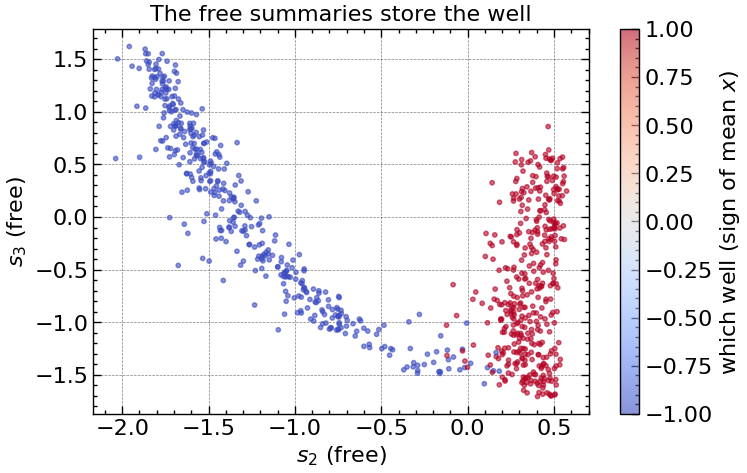

In [27]:
# which well: +1 right, -1 left (sign of the mean of the series in physical units)
x_real = Xte * stats["x_std"] + stats["x_mean"]
well = np.sign(x_real.mean(1))

# can we guess the well from the parameter summaries or from the free ones?
# (the well is only +1 or -1, so here we look at the R^2 and not at the MI)
r2_param = decodable_mi(S_te[:, :2], well)[1]
r2_free = decodable_mi(S_te[:, 2:], well)[1]
print(f"guess the well from (s0, s1): R^2 = {r2_param:.2f}")
print(f"guess the well from (s2, s3): R^2 = {r2_free:.2f}")

fig,ax = plt.subplots(figsize=(8,5))
sc = ax.scatter(S_te[:, 2], S_te[:, 3], c=well, cmap="coolwarm", s=10, alpha=0.6)
fig.colorbar(sc, ax=ax, label="which well (sign of mean $x$)")
ax.set_title("The free summaries store the well")
ax.set_xlabel("$s_2$ (free)")
ax.set_ylabel("$s_3$ (free)")
plt.show()

From $(s_0,s_1)$ we can't guess the well at all ($R^2\approx 0$), while from the free summaries we guess it almost perfectly ($R^2$ close to 1): the network used the spare dimensions to store which well the marble is in, without anybody telling it. This is the extra "order parameter" of the paper and the reason why we need $q>p$ (same thing as the clusters in the latent space of the solar dynamo).

It's not in contradiction with $\text{MI}(s,\varepsilon)\approx 0$: the well is decided by the warm-up noise, which is thrown away and never given to the decoder, so the encoder has to store it. The $\varepsilon$ in $\text{MI}(s,\varepsilon)$ is the noise of the observed window, which the decoder gets.

## Conclusions
1. The ENCA works on the bistable model: both parameters are recovered ($\sigma$ too, thanks to the increments and the std pooling) and the series is rebuilt from 4 numbers plus the noise.
2. Information theory confirms that the compression is selective: the summaries keep about as much information about the parameters as the data ($\text{MI}(s,\theta)\approx\text{MI}(X,\theta)$, sufficiency), and nothing about the noise ($\text{MI}(s,\varepsilon)\approx 0$, concentration), while the series itself carries a lot of information about the noise.
3. More filters $\to$ more information on $\sigma$ $\to$ better recovery of $\sigma$: MI is a good diagnostic of the compression.
4. A plain VAE with the same latent size keeps $a$ but loses $\sigma$, also changing $\beta$: giving the noise to the decoder is what makes the difference.
5. The free summaries store which well the marble is in: that's why we need more summaries than parameters ($q>p$).

Next step: the same pipeline on the solar dynamo.